# DENSE VAE TRAINING

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import h5py

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

2026-06-24 14:58:25.228724: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-24 14:58:25.313601: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
BACKGROUND_FILE = "../data/datasets/dense/background_dense_dataset.h5"

with h5py.File(BACKGROUND_FILE, "r") as f:
    X_train = f["X_train"][:].astype(np.float32)
    X_val = f["X_val"][:].astype(np.float32)
    X_test = f["X_test"][:].astype(np.float32)

print(f"{'X_train':<10}: {X_train.shape}")
print(f"{'X_val':<10}: {X_val.shape}")
print(f"{'X_test':<10}: {X_test.shape}")

X_train   : (8609225, 57)
X_val     : (2152307, 57)
X_test    : (2690383, 57)


In [3]:
DENSE_VAE_MODELS_DIR = "../models/dense_VAE"
os.makedirs(DENSE_VAE_MODELS_DIR, exist_ok=True)

MODEL_NAME = "dense_vae_3"

SAVE_WEIGHTS_PATH = os.path.join(DENSE_VAE_MODELS_DIR, f"{MODEL_NAME}.weights.h5")
SAVE_ENCODER_PATH = os.path.join(DENSE_VAE_MODELS_DIR, f"{MODEL_NAME}_encoder.keras")
SAVE_DECODER_PATH = os.path.join(DENSE_VAE_MODELS_DIR, f"{MODEL_NAME}_decoder.keras")

In [4]:
N_OBJ = 19
INPUT_DIM = 57
PT_COLS = [i * 3 for i in range(N_OBJ)]
PT_STD = X_train[:, PT_COLS].std() + 1e-8

W_CURR = {"pt": 1.0, "eta": 1.0, "phi": 0.5}
LATENT_DIM = 16
BETA = 0.000001

def reconstruction_event_loss(y_true, y_pred, pt_std=PT_STD, weights=W_CURR):
    y_true = tf.reshape(y_true, (-1, 19, 3))
    y_pred = tf.reshape(y_pred, (-1, 19, 3))

    mask = tf.cast(tf.not_equal(y_true[:, :, 0:1], 0.0), tf.float32)
    n_present = tf.maximum(tf.reduce_sum(mask, axis=[1, 2]), 1.0)

    pt_true = y_true[:, :, 0:1]
    pt_pred = y_pred[:, :, 0:1]
    pt_loss = tf.square(pt_true - pt_pred) / (pt_std ** 2)

    eta_true = y_true[:, :, 1:2]
    eta_pred = y_pred[:, :, 1:2]
    eta_loss = tf.square((eta_true - eta_pred) / 3.0)

    phi_true = y_true[:, :, 2:3]
    phi_pred = y_pred[:, :, 2:3]
    dphi = tf.atan2(tf.sin(phi_true - phi_pred), tf.cos(phi_true - phi_pred))
    phi_loss = tf.square(dphi)

    total = (
        weights["pt"] * pt_loss
        + weights["eta"] * eta_loss
        + weights["phi"] * phi_loss
    )
    total *= mask

    evt_reco = tf.reduce_sum(total, axis=[1, 2]) / n_present
    return evt_reco

In [5]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps


def build_encoder(input_dim=57, latent_dim=16):
    inp = keras.Input(shape=(input_dim,), name="encoder_input")
    x = layers.BatchNormalization()(inp)
    x = layers.Dense(48, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)
    x = layers.Dense(32, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)

    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling(name="z")([z_mean, z_log_var])

    return keras.Model(inp, [z_mean, z_log_var, z], name="encoder")


def build_decoder(input_dim=57, latent_dim=16):
    latent_inputs = keras.Input(shape=(latent_dim,), name="decoder_input")
    x = layers.Dense(32, use_bias=False)(latent_inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)
    x = layers.Dense(48, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)
    out = layers.Dense(input_dim, name="reconstruction")(x)

    return keras.Model(latent_inputs, out, name="decoder")


class DenseVAE(keras.Model):
    def __init__(self, encoder, decoder, beta=0.01, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta

        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.reco_loss_tracker = keras.metrics.Mean(name="reco_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reco_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, inputs, training=False):
        z_mean, z_log_var, z = self.encoder(inputs, training=training)
        reconstruction = self.decoder(z, training=training)
        return reconstruction

    def compute_losses(self, x, reconstruction, z_mean, z_log_var):
        reco_evt = reconstruction_event_loss(x, reconstruction)
        reco_loss = tf.reduce_mean(reco_evt)

        kl_evt = -0.5 * tf.reduce_sum(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
            axis=1,
        )
        kl_loss = tf.reduce_mean(kl_evt)

        total_loss = reco_loss + self.beta * kl_loss
        return total_loss, reco_loss, kl_loss

    def train_step(self, data):
        x = data[0] if isinstance(data, tuple) else data

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x, training=True)
            reconstruction = self.decoder(z, training=True)
            total_loss, reco_loss, kl_loss = self.compute_losses(x, reconstruction, z_mean, z_log_var)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reco_loss_tracker.update_state(reco_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reco_loss": self.reco_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        z_mean, z_log_var, z = self.encoder(x, training=False)
        reconstruction = self.decoder(z, training=False)
        total_loss, reco_loss, kl_loss = self.compute_losses(x, reconstruction, z_mean, z_log_var)

        self.total_loss_tracker.update_state(total_loss)
        self.reco_loss_tracker.update_state(reco_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reco_loss": self.reco_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [6]:
encoder = build_encoder(input_dim=INPUT_DIM, latent_dim=LATENT_DIM)
decoder = build_decoder(input_dim=INPUT_DIM, latent_dim=LATENT_DIM)
dense_vae = DenseVAE(encoder=encoder, decoder=decoder, beta=BETA, name="dense_vae")

dense_vae.compile(optimizer=keras.optimizers.Adam(1e-3))

_ = dense_vae(tf.zeros((1, INPUT_DIM), dtype=tf.float32))

encoder.summary()
decoder.summary()

I0000 00:00:1782305931.590841   32452 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13760 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:07.0, compute capability: 7.5


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 57)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 57)        │        228 │ encoder_input[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 48)        │      2,736 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48)        │        192 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 48)        │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      1,536 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 32)        │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 16)        │        528 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 16)        │        528 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Sampling)        │ (None, 16)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,876 (22.95 KB)

 Trainable params: 5,602 (21.88 KB)

...

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 48)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 48)             │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 57)             │         2,793 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,161 (20.16 KB)

 Trainable params: 5,001 (19.54 KB)

 Non-trainable params: 160 (640.00 B)

In [7]:
EPOCHS = 100
BATCH_SIZE = 1024

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1),
    keras.callbacks.ModelCheckpoint(
        SAVE_WEIGHTS_PATH,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
]

history_vae = dense_vae.fit(
    X_train,
    validation_data=(X_val,),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

dense_vae.load_weights(SAVE_WEIGHTS_PATH)
dense_vae.encoder.save(SAVE_ENCODER_PATH)
dense_vae.decoder.save(SAVE_DECODER_PATH)

print(f"Saved best weights: {SAVE_WEIGHTS_PATH}")
print(f"Saved encoder: {SAVE_ENCODER_PATH}")
print(f"Saved decoder: {SAVE_DECODER_PATH}")

Epoch 1/100


2026-06-24 14:59:02.009559: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f02d8003a60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-24 14:59:02.009596: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-06-24 14:59:02.118618: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-24 14:59:02.644368: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300


  40/8408 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step - kl_loss: 20140.1164 - loss: 7.6451 - reco_loss: 7.6250

I0000 00:00:1782305945.565253   32578 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8408/8408 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - kl_loss: 1191.3305 - loss: 1.2737 - reco_loss: 1.2725
Epoch 1: val_loss improved from None to 0.03612, saving model to ../models/dense_VAE/dense_vae_3.weights.h5

Epoch 1: finished saving model to ../models/dense_VAE/dense_vae_3.weights.h5
8408/8408 ━━━━━━━━━━━━━━━━━━━━ 56s 6ms/step - kl_loss: 305.8617 - loss: 0.3977 - reco_loss: 0.3974 - val_kl_loss: 143.1055 - val_loss: 0.0361 - val_reco_loss: 0.0360 - learning_rate: 0.0010
Epoch 2/100
8403/8408 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - kl_loss: 137.7687 - loss: 0.0453 - reco_loss: 0.0451
Epoch 2: val_loss improved from 0.03612 to 0.02162, saving model to ../models/dense_VAE/dense_vae_3.weights.h5

Epoch 2: finished saving model to ../models/dense_VAE/dense_vae_3.weights.h5
8408/8408 ━━━━━━━━━━━━━━━━━━━━ 43s 5ms/step - kl_loss: 132.8901 - loss: 0.0412 - reco_loss: 0.0410 - val_kl_loss: 125.2081 - val_loss: 0.0216 - val_reco_loss: 0.0215 - learning_rate: 0.0010
Epoch 3/100
8402/8408 ━━━━━━━━━━━━━━

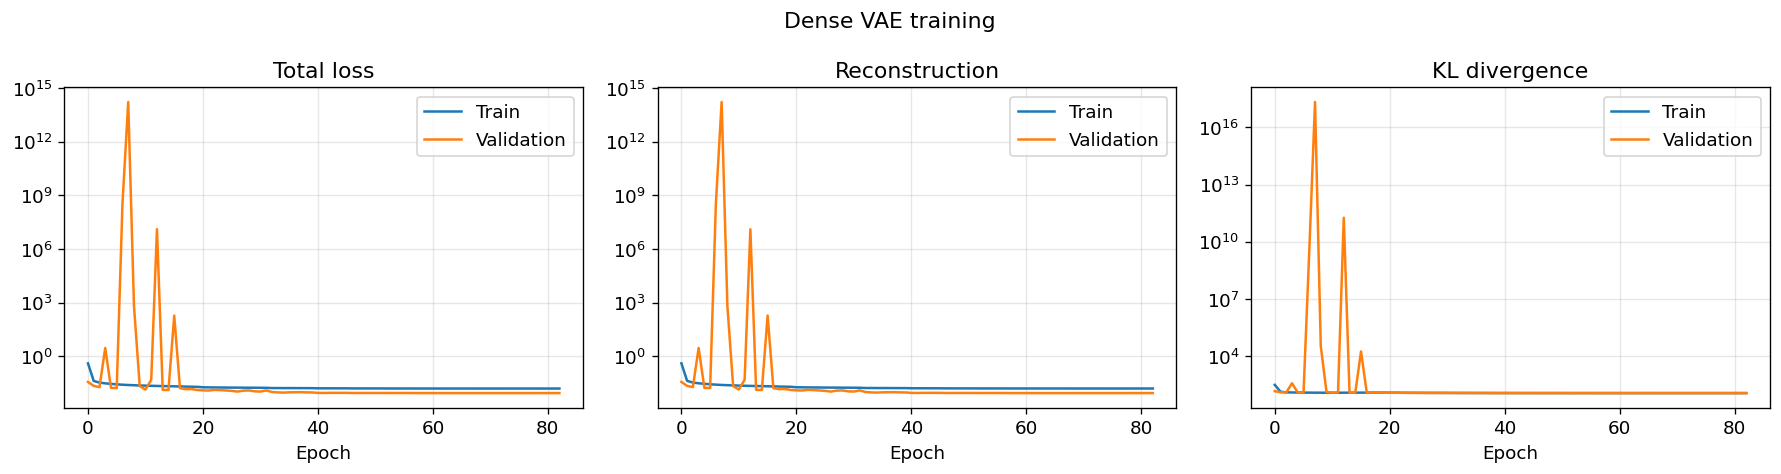

In [8]:
def plot_training_history(history, title="Dense VAE training"):
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    axs[0].semilogy(history.history["loss"], label="Train")
    axs[0].semilogy(history.history["val_loss"], label="Validation")
    axs[0].set_title("Total loss")
    axs[0].set_xlabel("Epoch")
    axs[0].legend()

    axs[1].semilogy(history.history["reco_loss"], label="Train")
    axs[1].semilogy(history.history["val_reco_loss"], label="Validation")
    axs[1].set_title("Reconstruction")
    axs[1].set_xlabel("Epoch")
    axs[1].legend()

    axs[2].semilogy(history.history["kl_loss"], label="Train")
    axs[2].semilogy(history.history["val_kl_loss"], label="Validation")
    axs[2].set_title("KL divergence")
    axs[2].set_xlabel("Epoch")
    axs[2].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_training_history(history_vae)

In [9]:
print("Training/export completed.")

Training/export completed.
